In [12]:
import pandas as pd
import numpy as np

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 2.3.3
numpy version: 2.0.2


In [13]:
import numpy as np

def gini_coefficient(incomes):
    incomes = np.array(incomes)
    n = len(incomes)
    mean_income = np.mean(incomes)
    
    # sum of |x_i - x_j| over all pairs
    total_diff = 0
    for i in range(n):
        for j in range(n):
            total_diff += abs(incomes[i] - incomes[j])
    
    gini = total_diff / (2 * n**2 * mean_income)
    return gini

    # everyone has the same income -> should print 0.0
print(gini_coefficient([50, 50, 50, 50]))

# one person has everything, rest have nothing 
# should print a number close to 1
print(gini_coefficient([1, 1, 1, 1000]))

# mixed example
print(gini_coefficient([50, 50, 70, 70, 70, 90, 150, 150, 150, 150]))

0.0
0.7470089730807578
0.226


In [14]:
def spectral_gap(transition_matrix):
    matrix = np.array(transition_matrix)
    eigenvalues = np.linalg.eigvals(matrix)
    
    # sort eigenvalues by absolute value, descending
    sorted_eigs = sorted(eigenvalues, key=abs, reverse=True)
    
    largest = sorted_eigs[0]
    second_largest = sorted_eigs[1]
    
    gap = 1 - abs(second_largest)
    return gap, second_largest

sticky_matrix = [
    [0.6, 0.3, 0.1],
    [0.2, 0.6, 0.2],
    [0.1, 0.3, 0.6]
]

gap, second_eig = spectral_gap(sticky_matrix)
print("Second eigenvalue:", second_eig)
print("Spectral gap:", gap)

mobile_matrix = [
    [0.34, 0.33, 0.33],
    [0.33, 0.34, 0.33],
    [0.33, 0.33, 0.34]
]

gap2, second_eig2 = spectral_gap(mobile_matrix)
print("Second eigenvalue:", second_eig2)
print("Spectral gap:", gap2)

Second eigenvalue: 0.4999999999999997
Spectral gap: 0.5000000000000002
Second eigenvalue: 0.010000000000000004
Spectral gap: 0.99


In [15]:
def simulate_population(transition_matrix, initial_distribution, generations, income_values):
    matrix = np.array(transition_matrix)
    distribution = np.array(initial_distribution) 
    
    history = []
    for gen in range(generations):
        # distribution is fraction of population in each group
        history.append(distribution.copy())
        distribution = distribution @ matrix  # one generation's transition
    
    return history

initial = [1.0, 0.0, 0.0]  # everyone starts in low income
history = simulate_population(sticky_matrix, initial, generations=10, income_values=[30, 60, 120])

for i, dist in enumerate(history):
    print(f"Generation {i}: {dist}")

Generation 0: [1. 0. 0.]
Generation 1: [0.6 0.3 0.1]
Generation 2: [0.43 0.39 0.18]
Generation 3: [0.354 0.417 0.229]
Generation 4: [0.3187 0.4251 0.2562]
Generation 5: [0.30186 0.42753 0.27061]
Generation 6: [0.293683 0.428259 0.278058]
Generation 7: [0.2896674 0.4284777 0.2818549]
Generation 8: [0.28768147 0.42854331 0.28377522]
Generation 9: [0.28669507 0.42856299 0.28474194]


In [16]:
def distribution_to_incomes(distribution, income_values, population_size=10000):
    incomes = []
    for fraction, income in zip(distribution, income_values):
        count = int(round(fraction * population_size))
        incomes.extend([income] * count)
    return incomes

In [17]:
final_distribution = history[-1]  # last generation 
income_values = [30, 60, 120]

incomes = distribution_to_incomes(final_distribution, income_values)
steady_state_gini = gini_coefficient(incomes)

print("Steady-state distribution:", final_distribution)
print("Steady-state Gini coefficient:", steady_state_gini)

Steady-state distribution: [0.28669507 0.42856299 0.28474194]
Steady-state Gini coefficient: 0.2680137249748106


In [18]:
history_mobile = simulate_population(mobile_matrix, initial, generations=20, income_values=[30, 60, 120])
final_dist_mobile = history_mobile[-1]

incomes_mobile = distribution_to_incomes(final_dist_mobile, income_values)
gini_mobile = gini_coefficient(incomes_mobile)

print("Mobile matrix steady-state distribution:", final_dist_mobile)
print("Mobile matrix Gini:", gini_mobile)
print("Mobile matrix spectral gap:", spectral_gap(mobile_matrix)[0])
print("---")
print("Sticky matrix Gini:", steady_state_gini)
print("Sticky matrix spectral gap:", spectral_gap(sticky_matrix)[0])

Mobile matrix steady-state distribution: [0.33333333 0.33333333 0.33333333]
Mobile matrix Gini: 0.2857142857142857
Mobile matrix spectral gap: 0.99
---
Sticky matrix Gini: 0.2680137249748106
Sticky matrix spectral gap: 0.5000000000000002


In [19]:
def random_transition_matrix(size=3):
    matrix = np.random.rand(size, size)
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix = matrix / row_sums
    return matrix

In [20]:
test_matrix = random_transition_matrix()
print(test_matrix)
print("Row sums:", test_matrix.sum(axis=1))

[[0.10901492 0.84371095 0.04727413]
 [0.6810354  0.0992546  0.21971   ]
 [0.48814251 0.20472907 0.30712841]]
Row sums: [1. 1. 1.]


In [21]:
spectral_gaps = []
gini_values = []

for i in range(50):
    matrix = random_transition_matrix(size=3)
    gap, _ = spectral_gap(matrix)
    
    # simulate to steady state
    initial = [1.0, 0.0, 0.0]
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    final_dist = history[-1]
    
    incomes = distribution_to_incomes(final_dist, income_values=[30, 60, 120])
    g = gini_coefficient(incomes)
    
    spectral_gaps.append(gap)
    gini_values.append(g)

print("Generated", len(spectral_gaps), "matrices")
print("First few spectral gaps:", spectral_gaps[:5])
print("First few Gini values:", gini_values[:5])

KeyboardInterrupt: 

In [25]:
def gini_coefficient(incomes):
    incomes = np.sort(np.array(incomes))
    n = len(incomes)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * incomes) - (n + 1) * np.sum(incomes)) / (n * np.sum(incomes))

In [26]:
print(gini_coefficient([50, 50, 50, 50]))
print(gini_coefficient([1, 1, 1, 1000]))
print(gini_coefficient([50, 50, 70, 70, 70, 90, 150, 150, 150, 150]))

0.0
0.7470089730807578
0.226


In [27]:
spectral_gaps = []
gini_values = []

for i in range(50):
    matrix = random_transition_matrix(size=3)
    gap, _ = spectral_gap(matrix)
    
    initial = [1.0, 0.0, 0.0]
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    final_dist = history[-1]
    
    incomes = distribution_to_incomes(final_dist, income_values=[30, 60, 120])
    g = gini_coefficient(incomes)
    
    spectral_gaps.append(gap)
    gini_values.append(g)

print("Generated", len(spectral_gaps), "matrices")
print("First few spectral gaps:", spectral_gaps[:5])
print("First few Gini values:", gini_values[:5])

Generated 50 matrices
First few spectral gaps: [np.float64(0.7995130313709639), np.float64(0.544314927331784), np.float64(0.9203900442936641), np.float64(0.6126474010328449), np.float64(0.7333810376464505)]
First few Gini values: [np.float64(0.3175398336517927), np.float64(0.2384427726763718), np.float64(0.28332934186471664), np.float64(0.29528259621422803), np.float64(0.26094665143397416)]


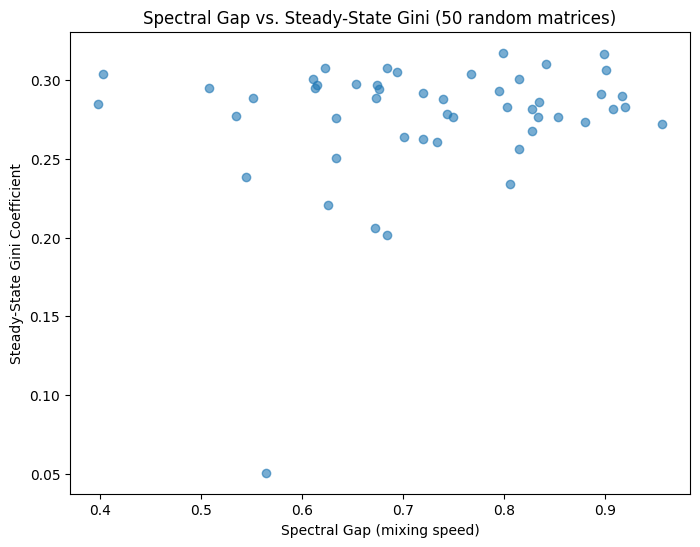

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(spectral_gaps, gini_values, alpha=0.6)
plt.xlabel("Spectral Gap (mixing speed)")
plt.ylabel("Steady-State Gini Coefficient")
plt.title("Spectral Gap vs. Steady-State Gini (50 random matrices)")
plt.show()

In [29]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 50.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 55.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 67.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]
